### Space weather data ARIMA test # 1 

In [1]:
import pandas as pd 

fn = r"C:\Data\fcc_database_v1.hdf5"

data = pd.read_hdf(fn) 

In [2]:
data.tail()

,DateTime,HMAEX,HMAEY,EMAX,SDEX,SDEY,SDEP,mlat,mlon,mlt,...,sigAPratio,Esw,Beta,AlfvenMach,Kp,nSunSpot,Dst,AE,AL,AU
280507,2022-12-31 19:00:00,31.26,74.06,74.52,14.76,25.95,14.88,67.365836,-24.280961,12.298359,...,NaN,-1.95,0.94,8.7,33.0,91.0,-25.0,NaN,NaN,NaN
280508,2022-12-31 20:00:00,33.48,89.31,93.87,16.83,22.00,19.57,67.365828,-24.280953,13.243339,...,NaN,0.49,1.15,9.3,33.0,91.0,-22.0,NaN,NaN,NaN
280509,2022-12-31 21:00:00,47.51,71.91,73.03,19.55,29.16,19.42,67.365820,-24.280946,14.200666,...,NaN,0.60,0.84,8.5,40.0,91.0,-25.0,NaN,NaN,NaN
280510,2022-12-31 22:00:00,27.24,51.95,53.00,11.97,19.66,11.93,67.365813,-24.280938,15.167596,...,NaN,-0.41,0.68,7.9,40.0,91.0,-26.0,NaN,NaN,NaN
280511,2022-12-31 23:00:00,17.21,32.84,36.79,7.32,12.79,10.48,67.365805,-24.280930,16.149475,...,NaN,-0.06,0.65,7.8,40.0,91.0,-24.0,NaN,NaN,NaN


In [3]:
data.describe()

,DateTime,HMAEX,HMAEY,EMAX,SDEX,SDEY,SDEP,mlat,mlon,mlt,...,sigAPratio,Esw,Beta,AlfvenMach,Kp,nSunSpot,Dst,AE,AL,AU
count,280512,270016.000000,270839.000000,269925.000000,270016.000000,270839.000000,269925.000000,280512.000000,280512.000000,280512.000000,...,228576.000000,255009.000000,253751.000000,253775.000000,279384.000000,279768.000000,280291.000000,237360.000000,237360.000000,237360.000000
mean,2006-12-31 23:30:00.000000256,40.315690,54.183961,62.140407,12.789249,17.376723,14.227346,68.424733,-26.531300,11.924116,...,0.004976,0.025879,2.673456,10.016686,19.026383,48.821481,-12.808777,192.570425,-119.599452,72.799848
min,1991-01-01 00:00:00,0.320000,0.380000,0.540000,0.130000,0.150000,0.170000,67.365805,-29.058951,0.156250,...,0.000000,-36.110000,0.000000,0.000000,0.000000,0.000000,-422.000000,3.000000,-2452.000000,-260.000000
25%,1998-12-31 23:45:00,8.150000,12.050000,13.660000,2.850000,4.240000,3.400000,67.925671,-27.898620,5.968539,...,0.002000,-0.580000,1.020000,7.100000,7.000000,11.000000,-20.000000,50.000000,-165.000000,23.000000
50%,2006-12-31 23:30:00,17.830000,27.340000,30.460000,6.130000,9.370000,7.190000,68.462056,-26.588398,11.865674,...,0.003000,0.030000,1.690000,9.200000,17.000000,36.000000,-9.000000,110.000000,-57.000000,47.000000
75%,2014-12-31 23:15:00,44.220000,62.610000,70.840000,14.660000,21.020000,16.750000,68.938598,-24.973739,17.792829,...,0.006000,0.630000,2.870000,11.700000,27.000000,78.000000,0.000000,266.000000,-22.000000,99.000000
max,2022-12-31 23:00:00,2429.450000,3128.440000,3129.110000,499.630000,678.410000,519.890000,69.329821,-24.280930,23.919582,...,0.421000,47.110000,359.890000,121.100000,90.000000,300.000000,95.000000,3195.000000,22.000000,1550.000000
std,NaN,64.712049,81.292551,93.765116,18.791687,23.342570,19.819023,0.580189,1.507520,6.918689,...,0.006055,1.373311,4.618566,4.910433,13.925129,46.213380,20.837392,206.569421,149.598030,71.856965


In [4]:

data.shape

(280512, 52)

In [5]:
data.info


<bound method DataFrame.info of                   DateTime   HMAEX   HMAEY    EMAX   SDEX    SDEY   SDEP  \
0      1991-01-01 00:00:00   64.62  188.23  199.01  16.66   37.35  22.11   
1      1991-01-01 01:00:00  214.82  355.69  357.68  49.02  111.36  48.58   
2      1991-01-01 02:00:00  193.01  151.16  226.23  47.63   46.41  51.54   
3      1991-01-01 03:00:00   41.47   29.52   43.72  14.96   13.79  15.94   
4      1991-01-01 04:00:00   70.29   48.47   73.12  25.06   14.81  25.15   
...                    ...     ...     ...     ...    ...     ...    ...   
280507 2022-12-31 19:00:00   31.26   74.06   74.52  14.76   25.95  14.88   
280508 2022-12-31 20:00:00   33.48   89.31   93.87  16.83   22.00  19.57   
280509 2022-12-31 21:00:00   47.51   71.91   73.03  19.55   29.16  19.42   
280510 2022-12-31 22:00:00   27.24   51.95   53.00  11.97   19.66  11.93   
280511 2022-12-31 23:00:00   17.21   32.84   36.79   7.32   12.79  10.48   

             mlat       mlon        mlt  ...  sigAPrati

In [6]:
data['DateTime'].min(), data['DateTime'].max()

(Timestamp('1991-01-01 00:00:00'), Timestamp('2022-12-31 23:00:00'))

In [7]:
type(data)

pandas.DataFrame

array([<Axes: xlabel='DateTime'>], dtype=object)

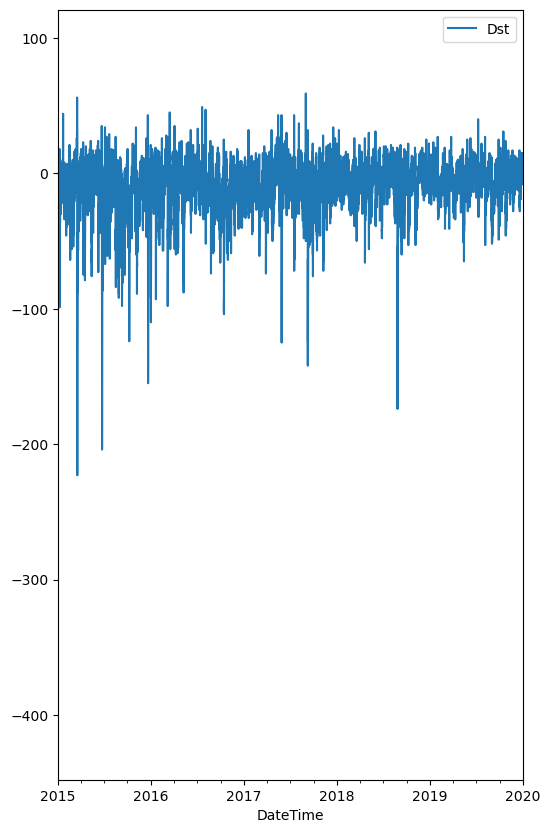

In [8]:
data.plot(x = 'DateTime', y = 'Dst', subplots = True, xlim = ('2015', '2020'), figsize =(6,10))

In [9]:
series = data.loc['2015-01-01':'2020-12-31' , 'Dst']

-7.648
92.94809599999999
201500
201999


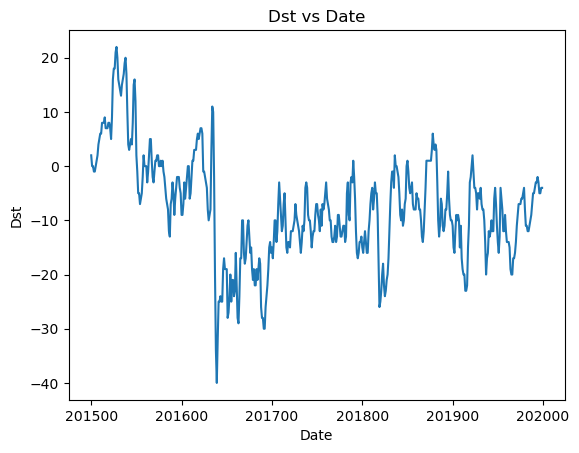

In [10]:
import numpy as np
import matplotlib.pyplot as plt

mean = np.mean(series)
print(mean)

variance = np.var(series)
print(variance)

print(series.index.min())
print(series.index.max())

plt.figure()
plt.plot(series.index,series) 
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst vs Date")
plt.show() 


2015-01-01 00:00:00
2020-12-31 23:00:00
52608


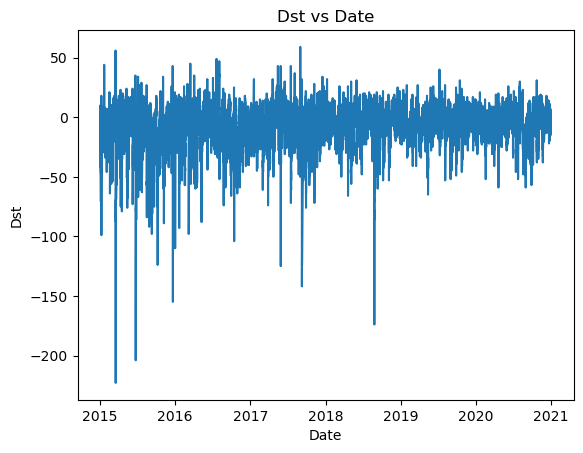

In [11]:
data['DateTime'] = pd.to_datetime(data['DateTime'])
data = data.sort_values('DateTime')
data = data.set_index('DateTime')

series = data.loc['2015-01-01':'2020-12-31', 'Dst']

print(series.index.min())
print(series.index.max())
print(len(series))

plt.figure()
plt.plot(series.index, series)
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst vs Date")
plt.show()

Let's plot the ACF and do a Dicky fuller test, we'll use the carrington rotation of 27 days (648 hours)

source https://nso.edu/data/nisp-data/synoptic-maps/#:~:text=Solar%20latitudes%20are

ADF Statistic: -18.157809227776983
p-value: 2.465970843675729e-30


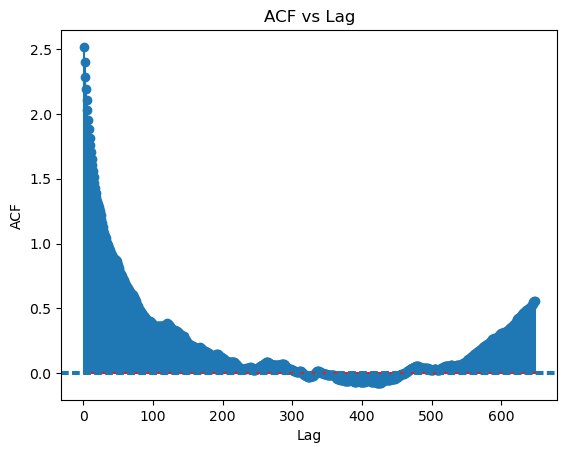

In [12]:

from statsmodels.tsa.stattools import adfuller

series_array = series.to_numpy()

acf_values = []


for lag in range(1, 649):
    products = [] 
    
    for i in range(len(series_array)):
         if i >= lag:
           mul = (series_array[i] - mean) * (series_array[i-lag] - mean) 
           
           products.append(float(mul))

    autocov = sum(products) / len(products)
    autocorr = autocov / variance

    acf_values.append(float(autocorr))
    
lags = list(range(1,649))

result = adfuller(series)

print("ADF Statistic:" , result[0])
print("p-value:", result[1])

critical_value = 1.96 / np.sqrt(52608) 

plt.figure()
plt.stem(lags,acf_values) 
plt.axhline(critical_value,linestyle='--')
plt.axhline(-critical_value,linestyle='--')
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("ACF vs Lag")
plt.show() 

ACF slowly decays indiciating non-stationarity. The Dicky fuller test argues, but clearly the data is not stationary. Let's difference the data 

0.00032315091147565913
13.605014437364506


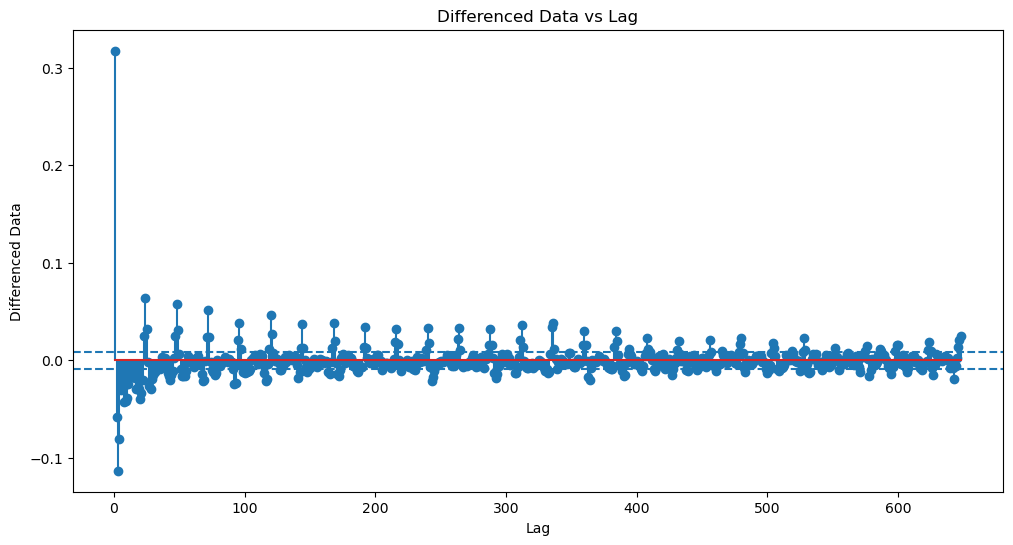

In [13]:
series_diff = np.diff(series_array)

diff_acf_values = []

diff_mean = np.mean(series_diff)
print(diff_mean)

diff_variance = np.var(series_diff)
print(diff_variance)

for lag in range(1, 649):
    products = [] 
    
    for i in range(len(series_diff)):
         if i >= lag:
           mul = (series_diff[i] - diff_mean) * (series_diff[i-lag] - diff_mean) 
           
           products.append(float(mul))

    diff_autocov = sum(products) / len(products)
    diff_autocorr = diff_autocov / diff_variance

    diff_acf_values.append(float(diff_autocorr))

critical_value = 1.96 / np.sqrt(len(series_diff)) 

plt.figure(figsize=(12,6))
plt.stem(lags,diff_acf_values) 
plt.axhline(critical_value,linestyle='--')
plt.axhline(-critical_value,linestyle='--')
plt.xlabel("Lag")
plt.ylabel("Differenced Data")
plt.title("Differenced Data vs Lag")
plt.show() 


Looks alot better, but not a clean decay. Likely due to noisy data? Clear spike at 1, so maybe we can choose a q = 1 . Let's check the PACF

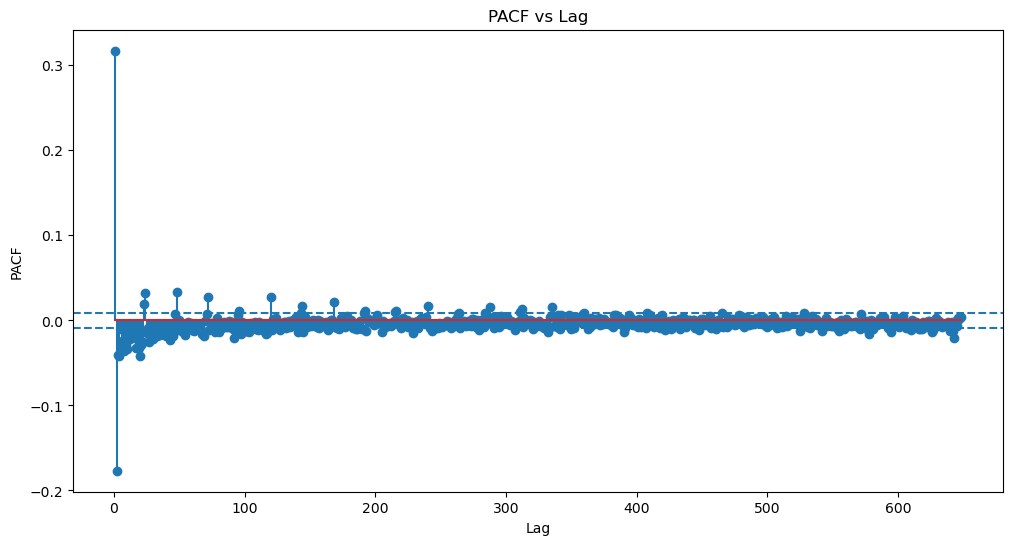

In [14]:
from statsmodels.tsa.stattools import pacf

pacf_values = pacf(series_diff, 648)

plt.figure(figsize=(12,6))
plt.stem(lags,pacf_values[1:])
plt.axhline(critical_value,linestyle='--')
plt.axhline(-critical_value,linestyle='--')
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.title("PACF vs Lag")
plt.show() 

PACF is also not clean, but does show a significant spike at both lags 1 and 2. In any case, we will use the arimad function to automate it. But first out of curiosity, we will also confirm the seasonality situation by specifically finding the time values at which the dst level is below 50. "The minimum value during a storm will be between −50 and approximately −600 nT." from wikipedia. I want to check this, because it looks seasonal to me from the ACF graph. 

In [15]:
dst_events = series[series < -50]

for t, v in dst_events.items():
    print(t, v)

2015-01-04 13:00:00 -51.0
2015-01-04 14:00:00 -56.0
2015-01-04 15:00:00 -55.0
2015-01-04 16:00:00 -62.0
2015-01-04 17:00:00 -51.0
2015-01-04 18:00:00 -56.0
2015-01-04 19:00:00 -58.0
2015-01-04 20:00:00 -61.0
2015-01-04 21:00:00 -71.0
2015-01-04 22:00:00 -61.0
2015-01-04 23:00:00 -52.0
2015-01-05 00:00:00 -62.0
2015-01-07 09:00:00 -66.0
2015-01-07 10:00:00 -97.0
2015-01-07 11:00:00 -99.0
2015-01-07 12:00:00 -93.0
2015-01-07 13:00:00 -93.0
2015-01-07 14:00:00 -95.0
2015-01-07 15:00:00 -90.0
2015-01-07 16:00:00 -80.0
2015-01-07 17:00:00 -66.0
2015-01-07 18:00:00 -54.0
2015-01-08 01:00:00 -52.0
2015-02-17 22:00:00 -61.0
2015-02-17 23:00:00 -62.0
2015-02-18 00:00:00 -64.0
2015-02-18 01:00:00 -57.0
2015-02-18 03:00:00 -53.0
2015-02-18 05:00:00 -52.0
2015-02-18 06:00:00 -56.0
2015-02-18 07:00:00 -58.0
2015-02-18 08:00:00 -57.0
2015-02-18 09:00:00 -53.0
2015-02-24 03:00:00 -52.0
2015-02-24 04:00:00 -53.0
2015-02-24 06:00:00 -54.0
2015-02-24 07:00:00 -56.0
2015-03-02 08:00:00 -54.0
2015-03-02 0

There is no clear 27 day pattern, although I do see it somewhat, there are storms in between the 27 day carrington rotation. So I will assume no clear seasonality, and I will move forward with the ARIMA test. 

In [16]:
from pmdarima import auto_arima

model = auto_arima(
    series,
    seasonal=False,      
    trace=True,          
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=278488.594, Time=44.82 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=286623.533, Time=0.86 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=281047.547, Time=1.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=279800.105, Time=3.39 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=286621.534, Time=0.42 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=41.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=279231.763, Time=8.79 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=278352.722, Time=59.77 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=58.98 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=65.77 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=278492.346, Time=46.61 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=278459.740, Time=61.13 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=59.49 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=70.02 sec
 ARIMA(3,1,2)(0,0,0)[0]        

Looks like ARIMA (4,1,1) is the best fit. Let's graph it vs the actual data and check out how it's fitting. 


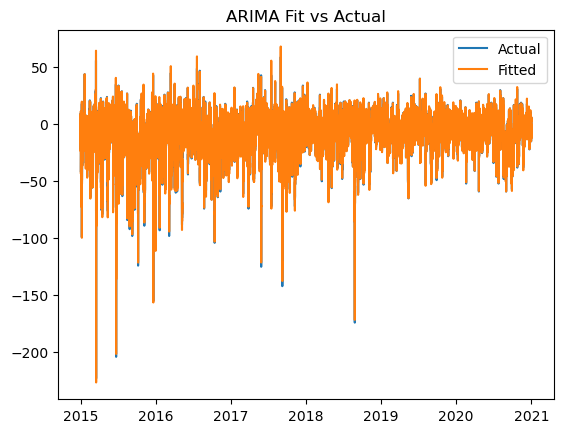

In [17]:
fitted_values = model.predict_in_sample()

plt.figure()
plt.plot(series, label="Actual")
plt.plot(fitted_values, label="Fitted")
plt.legend()
plt.title("ARIMA Fit vs Actual")
plt.show() 

Model looks good. Let's check the residuals and get the corresponding ACF. We expect it to look like white noise. 

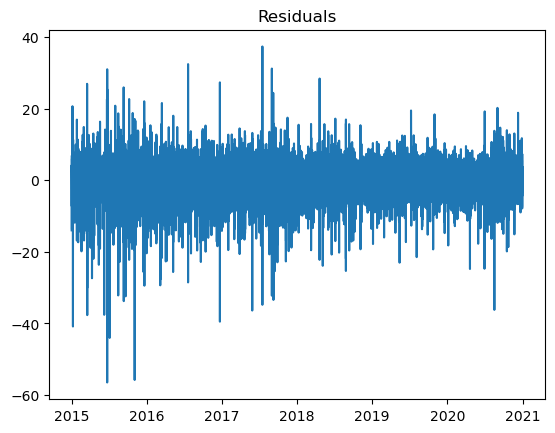

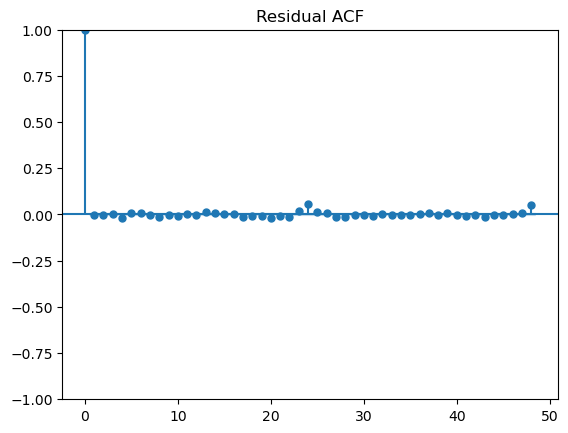

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = model.resid()

plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.show() 

plot_acf(residuals)
plt.title("Residual ACF")
plt.show()


In [19]:
print(len(residuals))

52608


In [24]:
from sampling_methods import sample_block

block_results = sample_block(residuals, 52608)
print(len(block_results))

52608


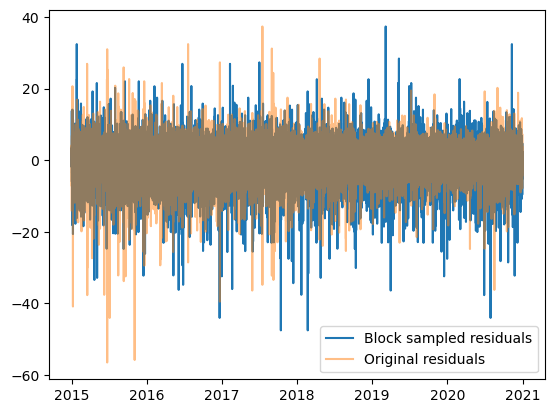

In [25]:
plt.figure()
plt.plot(residuals.index, block_results, label="Block sampled residuals")
plt.plot(residuals.index, residuals, label="Original residuals", alpha=0.5)
plt.legend()
plt.show()

In [26]:
from scipy.stats import ks_2samp

block_ks_stat, block_p_value = ks_2samp(residuals, block_results)

print("Block KS Statistic:", block_ks_stat)
print("Block P-value:", block_p_value)

Block KS Statistic: 0.003535583941605913
Block P-value: 0.8962087501200791


In [27]:
from diagnostics import diagnostic_plot

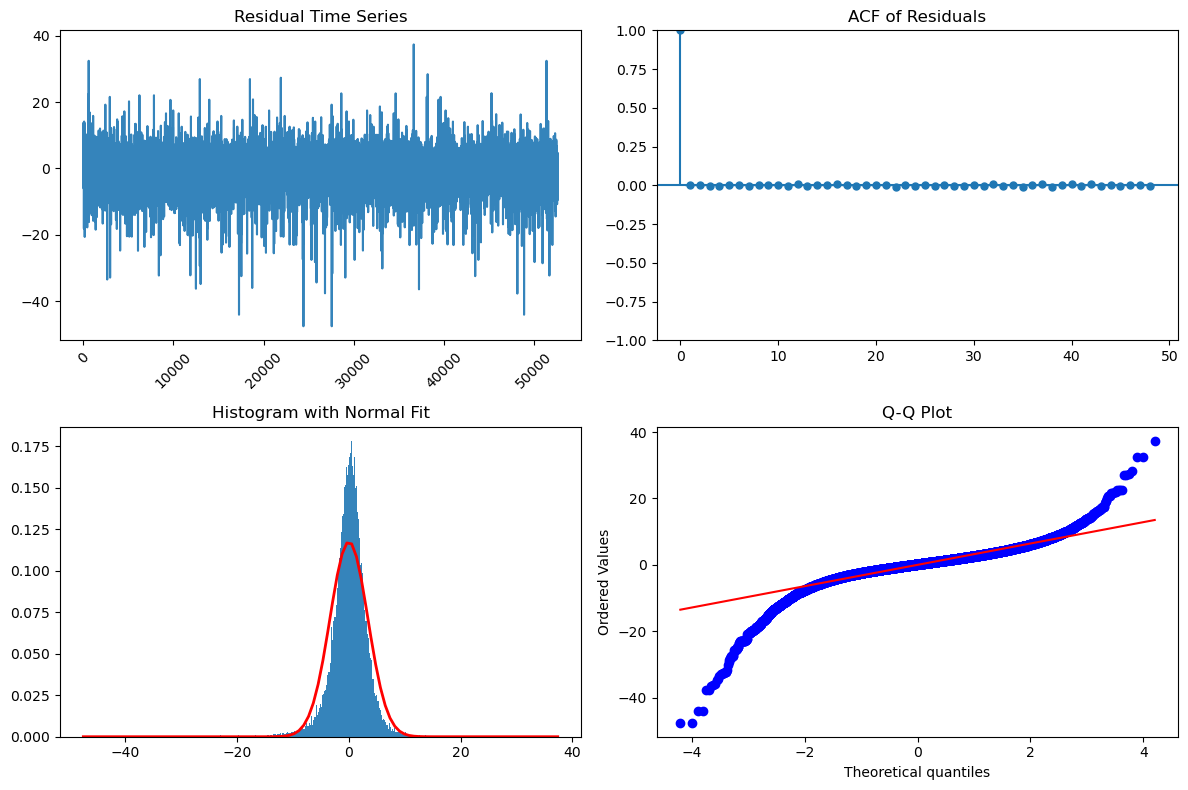

In [28]:
diagnostic_plot(block_results)

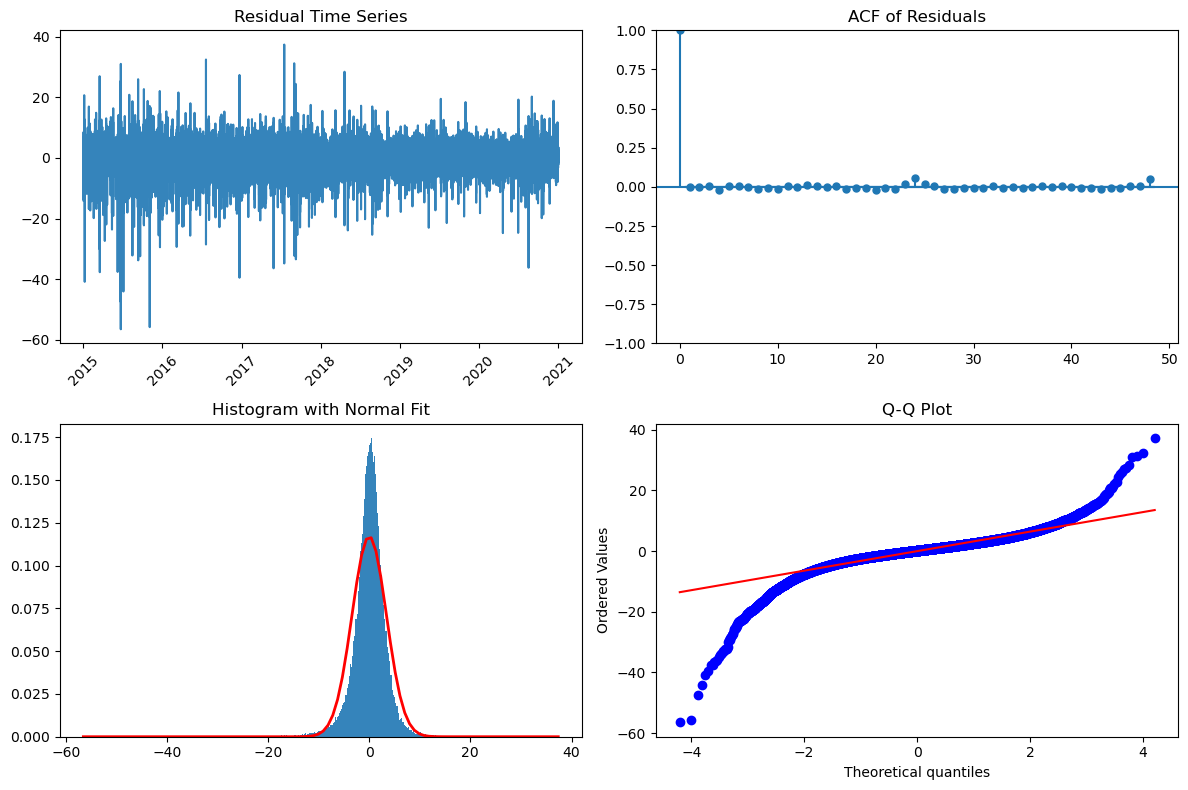

In [29]:
diagnostic_plot(residuals)

Our model looks good. Let's forecast for 6 hours ahead, and well compare that to the original model to check, and see how accurate it is. 

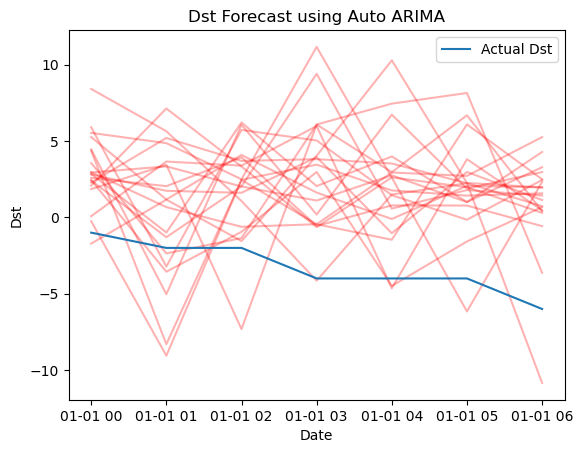

In [62]:
n_periods = 7

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[-1] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'Dst'] 

ensemble_block = []

for i in range(20):

    block_results = sample_block(residuals, n_periods)

    forecast_perturbed = forecast + block_results

    ensemble_block.append(forecast_perturbed)

for i in range(20):
    plt.plot(forecast_index, ensemble_block[i], alpha=0.3, color='red')

plt.plot(future_series.index, future_series, label='Actual Dst')

plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst Forecast using Auto ARIMA")
plt.legend()
plt.show()


Looks okay. But seems to follow the direction somewhat. Let's compute the RMSE and MAE error for future comparison. 

In [63]:
error = future_series.to_numpy() - forecast

mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))

print("Errors:", error)
print("MAE:", mae)
print("RMSE:", rmse)

Errors: 2021-01-01 00:00:00   -3.921859
2021-01-01 01:00:00   -4.674084
2021-01-01 02:00:00   -4.376394
2021-01-01 03:00:00   -6.098140
2021-01-01 04:00:00   -5.849655
2021-01-01 05:00:00   -5.622985
2021-01-01 06:00:00   -7.411957
Freq: h, dtype: float64
MAE: 5.422153445829347
RMSE: 5.533556181514986


Let's try the same with the solwar wind Esw

array([<Axes: xlabel='DateTime'>], dtype=object)

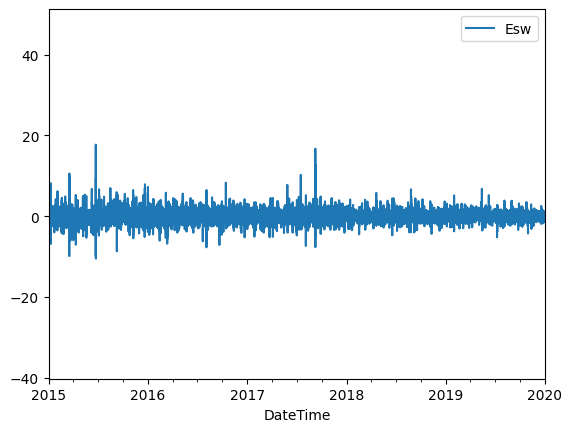

In [13]:
data.plot( x = 'DateTime' , y = 'Esw' , subplots = True, xlim = ('2015','2020'))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sampling_methods import sample_gaussian, sample_empirical, sample_kde, sample_block

data['DateTime'] = pd.to_datetime(data['DateTime'])
data = data.sort_values('DateTime')
data = data.set_index('DateTime')

series = data.loc['2015-01-01':'2020-12-31', 'Esw'].dropna()

model = auto_arima(
    series,
    seasonal=False,      
    trace=True,          
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=127755.151, Time=6.56 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=158750.133, Time=0.28 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=128355.435, Time=0.66 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=137766.186, Time=1.23 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=127939.194, Time=2.83 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=127804.427, Time=9.09 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=127765.088, Time=17.38 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=127755.199, Time=7.33 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=128271.206, Time=1.43 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=127782.826, Time=3.96 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=127753.781, Time=9.26 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=128071.957, Time=1.11 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=127754.689, Time=12.75 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=128288.561, Time=0.87 sec
 AR

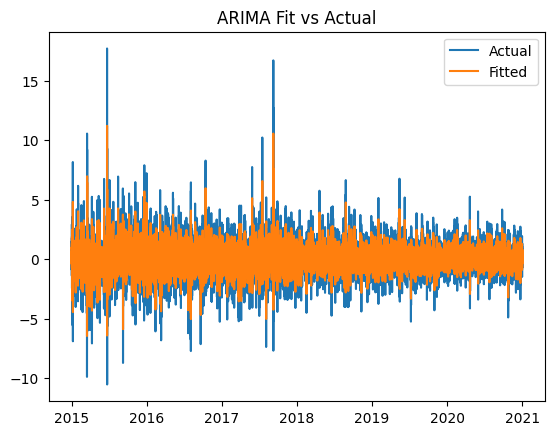

In [3]:
fitted_values = model.predict_in_sample()

plt.figure()
plt.plot(series, label="Actual")
plt.plot(fitted_values, label="Fitted")
plt.legend()
plt.title("ARIMA Fit vs Actual")
plt.show() 

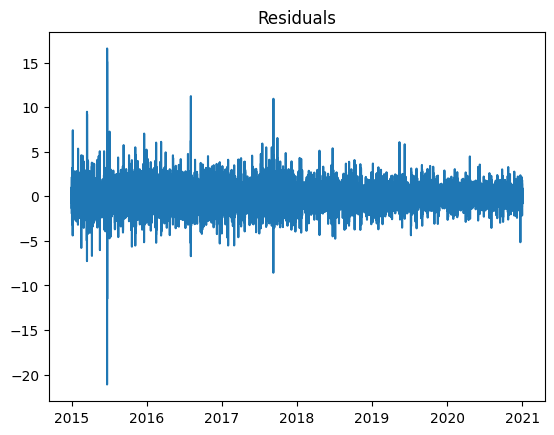

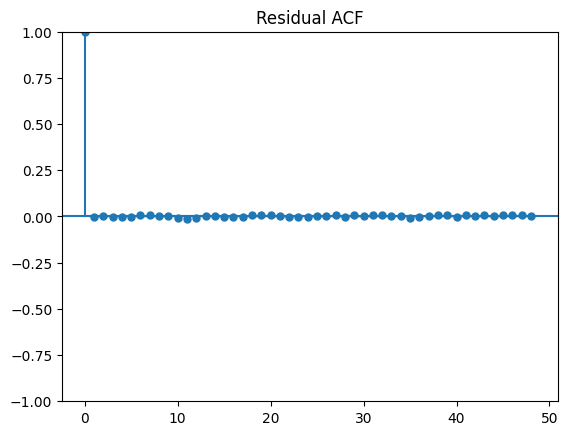

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = model.resid()

plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.show() 

plot_acf(residuals)
plt.title("Residual ACF")
plt.show()

c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


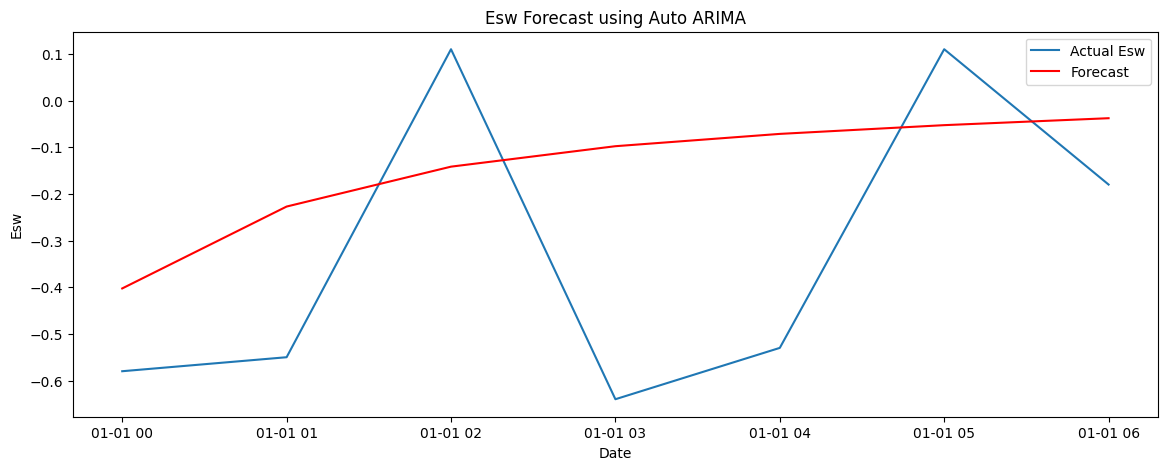

In [12]:
n_periods = 7

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[-1] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'Esw']


plt.figure(figsize=(14,5))

plt.plot(future_series.index, future_series, label='Actual Esw')
plt.plot(forecast_index, forecast, label='Forecast', color='red')

plt.xlabel("Date")
plt.ylabel("Esw")
plt.title("Esw Forecast using Auto ARIMA")
plt.legend()
plt.show()

In [13]:
error = future_series.to_numpy() - forecast

mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))

print("Errors:", error)
print("MAE:", mae)
print("RMSE:", rmse)

Errors: 52429   -0.177401
52430   -0.322877
52431    0.251644
52432   -0.542183
52433   -0.458562
52434    0.162716
52435   -0.142166
dtype: float64
MAE: 0.2939355204159372
RMSE: 0.3273212753716886


Let's try the same process for HMAEX, but using a shorter window of one year.

array([<Axes: xlabel='DateTime'>], dtype=object)

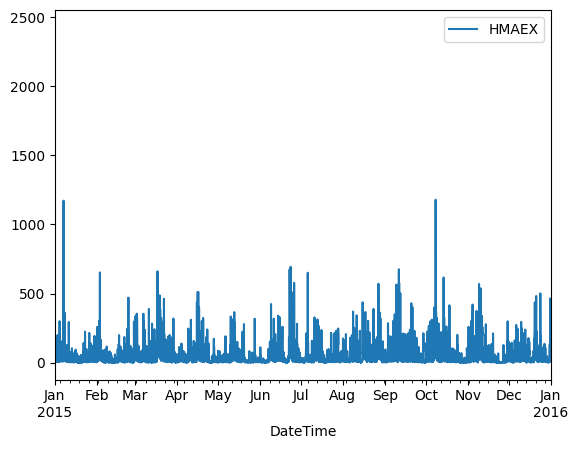

In [4]:
data.plot( x = 'DateTime' , y = 'HMAEX' , subplots = True, xlim = ('2015','2016'))

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

data['DateTime'] = pd.to_datetime(data['DateTime'])
data = data.sort_values('DateTime')
data = data.set_index('DateTime')

series = data.loc['2015-01-01':'2015-01-31', 'HMAEX'].dropna()

model = auto_arima(
    series,
    seasonal=False,      
    trace=True,          
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8231.091, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8185.481, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8144.211, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8229.091, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=8045.589, Time=0.16 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=8015.196, Time=0.31 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=8016.782, Time=0.46 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=8016.830, Time=0.39 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=8018.646, Time=0.48 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=8013.302, Time=0.16 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=8043.613, Time=0.09 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=8014.9

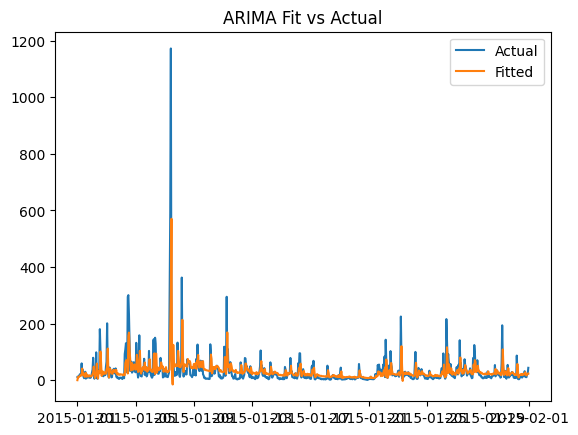

In [6]:
fitted_values = model.predict_in_sample()

plt.figure()
plt.plot(series, label="Actual")
plt.plot(fitted_values, label="Fitted")
plt.legend()
plt.title("ARIMA Fit vs Actual")
plt.show() 

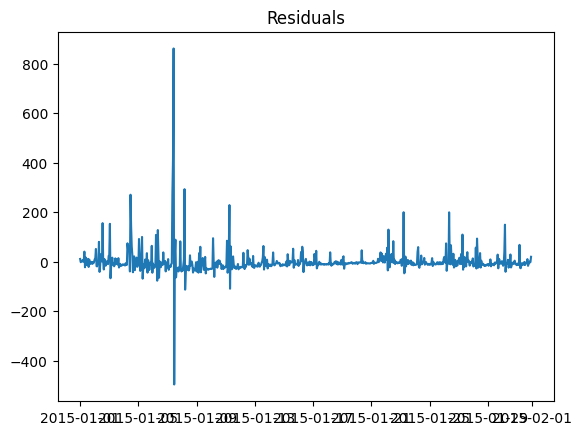

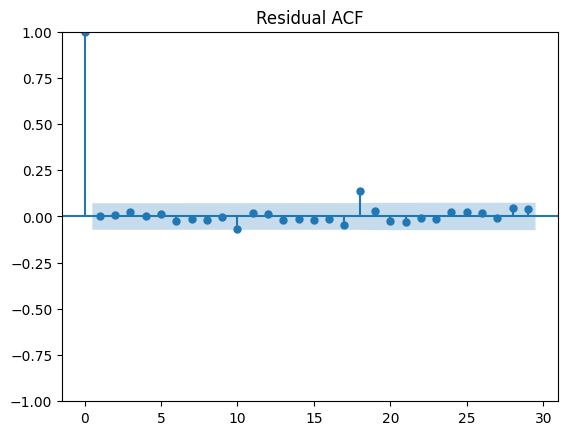

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = model.resid()

plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.show() 

plot_acf(residuals)b
plt.title("Residual ACF")
plt.show()

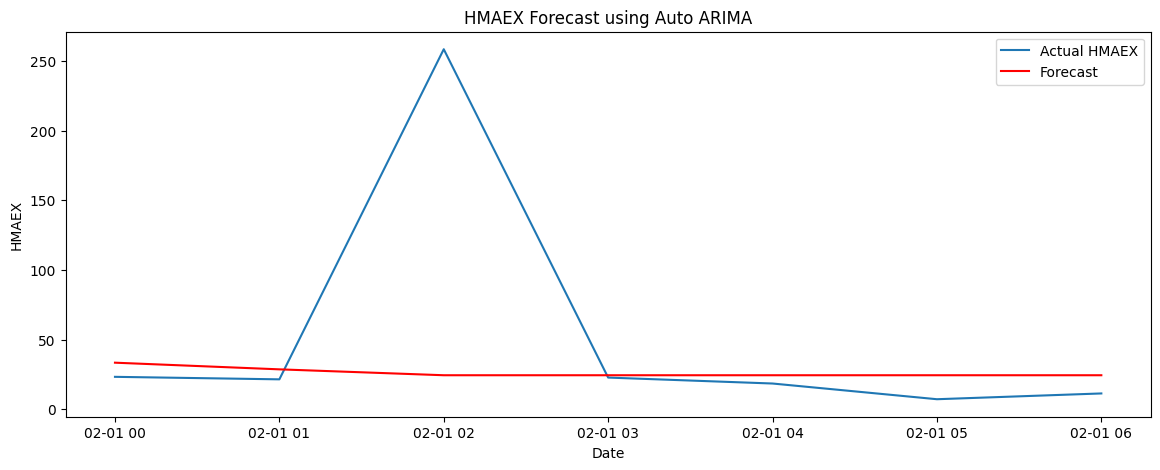

In [10]:
n_periods = 7

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[-1] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'HMAEX']


plt.figure(figsize=(14,5))

plt.plot(future_series.index, future_series, label='Actual HMAEX')
plt.plot(forecast_index, forecast, label='Forecast', color='red')

plt.xlabel("Date")
plt.ylabel("HMAEX")
plt.title("HMAEX Forecast using Auto ARIMA")
plt.legend()
plt.show()

In [ ]:
error = future_series.to_numpy() - forecast

mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))

print("Errors:", error)
print("MAE:", mae)
print("RMSE:", rmse)b

Errors: 2015-02-01 00:00:00    -10.163449
2015-02-01 01:00:00     -7.180256
2015-02-01 02:00:00    234.164697
2015-02-01 03:00:00     -1.675303
2015-02-01 04:00:00     -5.945303
2015-02-01 05:00:00    -17.225303
2015-02-01 06:00:00    -13.075303
Freq: h, dtype: float64
MAE: 41.347087869594866
RMSE: 89.03754011962894


Quite inaccurate, could be because of the shorter window ( I think this is likely) but I cannot say for sure that this is the sole reason. Let's try for AE, this time we will use a longer window of 18 years. 

array([<Axes: xlabel='DateTime'>], dtype=object)

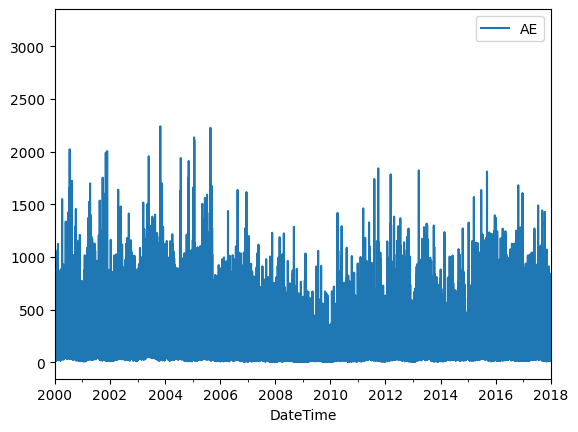

In [3]:
data.plot( x = 'DateTime' , y = 'AE' , subplots = True, xlim = ('2000','2018'))

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

data['DateTime'] = pd.to_datetime(data['DateTime'])
data = data.sort_values('DateTime')
data = data.set_index('DateTime')

series = data.loc['2000-01-01':'2018-01-31', 'AE'].dropna()

model = auto_arima(
    series,
    seasonal=False,      
    trace=True,          
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1925507.829, Time=49.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1946551.122, Time=1.72 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1946416.890, Time=2.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1946256.876, Time=14.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1946549.122, Time=0.87 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1925880.053, Time=41.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1927101.598, Time=36.84 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=92.48 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1923842.175, Time=123.55 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=72.98 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=1924002.073, Time=133.64 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=133.61 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=96.15 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=1925861.145, Time=105.16 sec
 ARIMA(2

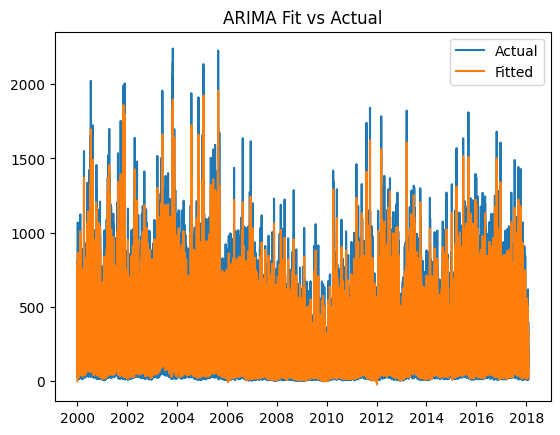

In [6]:
fitted_values = model.predict_in_sample()

plt.figure()
plt.plot(series, label="Actual")
plt.plot(fitted_values, label="Fitted")
plt.legend()
plt.title("ARIMA Fit vs Actual")
plt.show() 

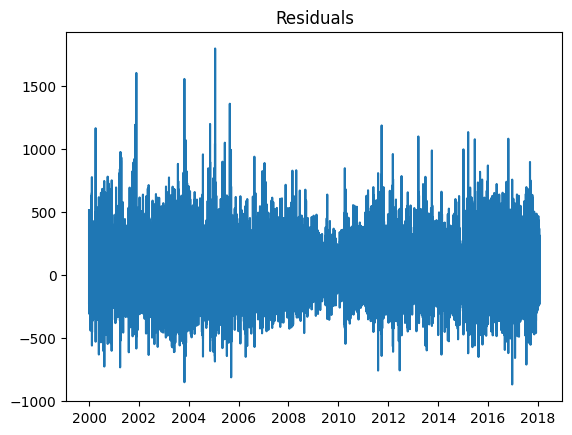

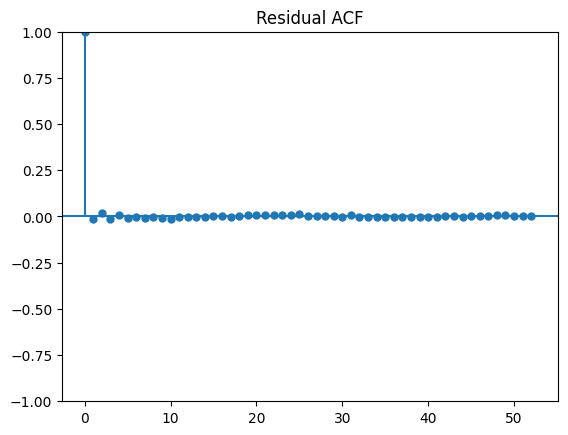

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = model.resid()

plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.show() 

plot_acf(residuals)
plt.title("Residual ACF")
plt.show()


c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


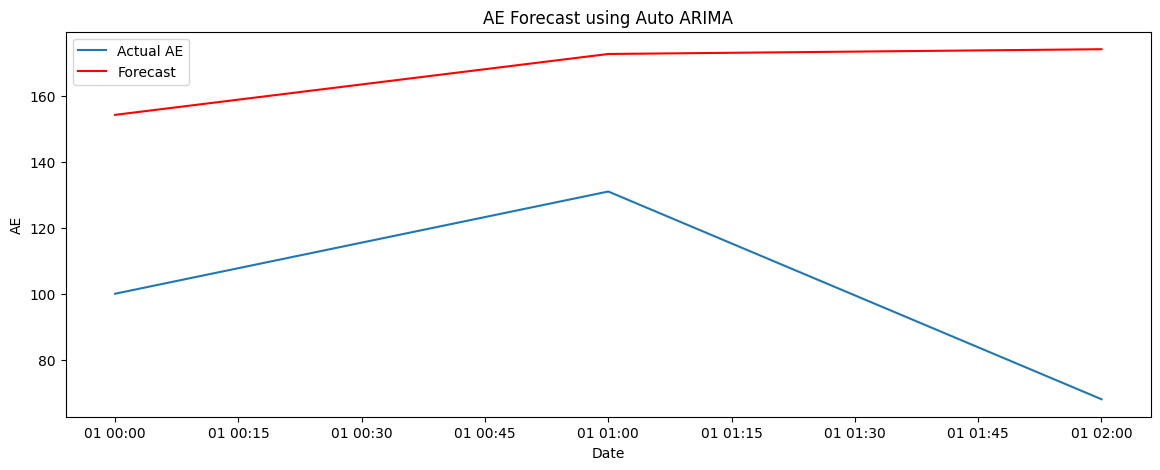

In [10]:

n_periods = 3

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[-1] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'AE']


plt.figure(figsize=(14,5))

plt.plot(future_series.index, future_series, label='Actual AE')
plt.plot(forecast_index, forecast, label='Forecast', color='red')

plt.xlabel("Date")
plt.ylabel("AE")
plt.title("AE Forecast using Auto ARIMA")
plt.legend()
plt.show()

In [11]:
error = future_series.to_numpy() - forecast

mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))

print("Errors:", error)
print("MAE:", mae)
print("RMSE:", rmse)

Errors: 157800    -54.251485
157801    -41.718844
157802   -106.160347
dtype: float64
MAE: 67.37689167755336
RMSE: 72.92394372897418


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


fn = r"C:\Data\fcc_database_v1.hdf5"

data = pd.read_hdf(fn)

data.shape

data.describe


<bound method NDFrame.describe of                   DateTime   HMAEX   HMAEY    EMAX   SDEX    SDEY   SDEP  \
0      1991-01-01 00:00:00   64.62  188.23  199.01  16.66   37.35  22.11   
1      1991-01-01 01:00:00  214.82  355.69  357.68  49.02  111.36  48.58   
2      1991-01-01 02:00:00  193.01  151.16  226.23  47.63   46.41  51.54   
3      1991-01-01 03:00:00   41.47   29.52   43.72  14.96   13.79  15.94   
4      1991-01-01 04:00:00   70.29   48.47   73.12  25.06   14.81  25.15   
...                    ...     ...     ...     ...    ...     ...    ...   
280507 2022-12-31 19:00:00   31.26   74.06   74.52  14.76   25.95  14.88   
280508 2022-12-31 20:00:00   33.48   89.31   93.87  16.83   22.00  19.57   
280509 2022-12-31 21:00:00   47.51   71.91   73.03  19.55   29.16  19.42   
280510 2022-12-31 22:00:00   27.24   51.95   53.00  11.97   19.66  11.93   
280511 2022-12-31 23:00:00   17.21   32.84   36.79   7.32   12.79  10.48   

             mlat       mlon        mlt  ...  sigAPra

<Axes: xlabel='DateTime'>

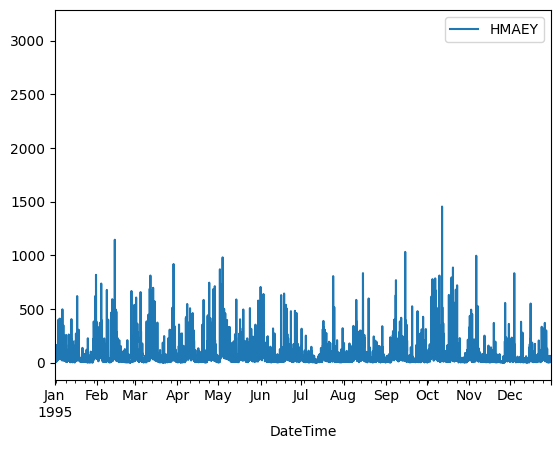

In [6]:
data.plot(x = 'DateTime', y = 'HMAEY' , xlim = ('1995-01-01', '1995-12-31'))

In [ ]:
from pmdarima import auto_arima  

data['DateTime'] = pd.to_datetime(data['DateTime'])
data = data.set_index('DateTime')

series = data.loc['1995-01-01' : '1995-12-31' , 'HMAEY'].dropna()

print(series)

model = auto_arima(
    series,
    seasonal = False,
    Trace = True, 
    stepwise = True 
)

print(model.summary())




DateTime
1995-01-01 00:00:00     9.11
1995-01-01 01:00:00    11.05
1995-01-01 02:00:00    12.67
1995-01-01 03:00:00     9.17
1995-01-01 04:00:00    25.34
                       ...  
1995-12-31 19:00:00    25.43
1995-12-31 20:00:00    16.47
1995-12-31 21:00:00    28.69
1995-12-31 22:00:00    41.52
1995-12-31 23:00:00    37.19
Name: HMAEY, Length: 8760, dtype: float64
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 8760
Model:               SARIMAX(1, 1, 4)   Log Likelihood              -50692.447
Date:                Fri, 01 May 2026   AIC                         101396.893
Time:                        22:19:18   BIC                         101439.360
Sample:                    01-01-1995   HQIC                        101411.364
                         - 12-31-1995                                         
Covariance Type:                  opg                                        

<function matplotlib.pyplot.show(close=None, block=None)>

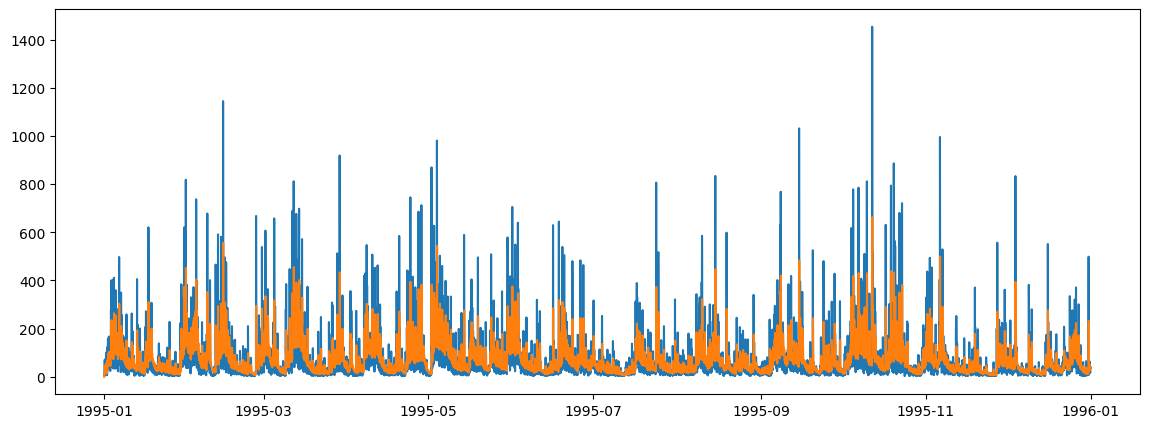

In [25]:
fitted_values = model.predict_in_sample()


plt.figure(figsize = (14,5))
plt.plot(series , label = "Actual")
plt.plot(fitted_values, label = "Fitted")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

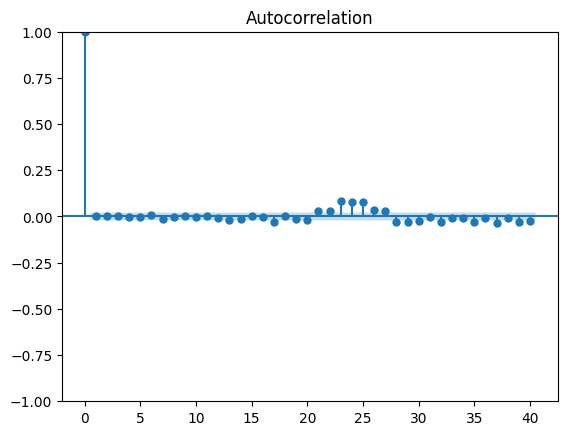

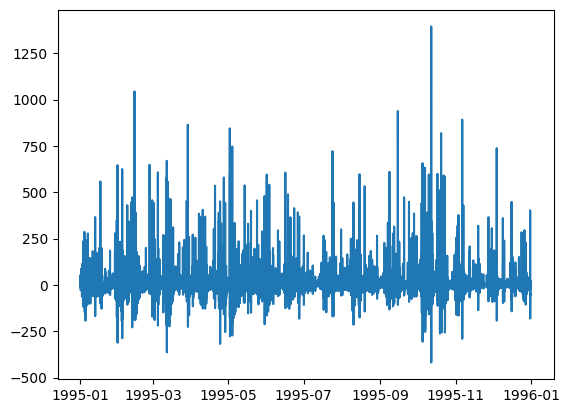

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = model.resid()


plt.figure()
plot_acf(residuals)
plt.show

plt.figure() 
plt.plot(residuals)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

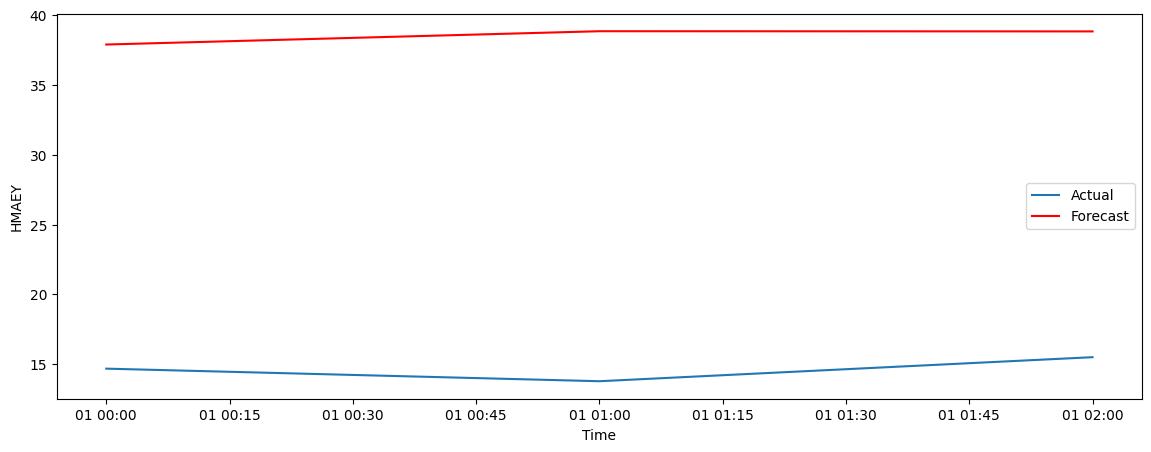

In [24]:
forecast = model.predict(n_periods = 3)

forecast_index = pd.date_range(
    start = series.index[-1] + pd.Timedelta(hours =1),
    freq = 'h',
    periods = 3
)

future_series = data.loc[forecast_index, 'HMAEY']

plt.figure(figsize = (14,5))
plt.plot(future_series.index, future_series, label = 'Actual')
plt.plot(forecast_index, forecast, label = 'Forecast', color = 'red')
plt.xlabel('Time')
plt.ylabel('HMAEY')
plt.legend() 
plt.show

In [ ]:
error = future_series.to_numpy() - forecast

RMSE = np.sqrt(np.mean(error**2))

MAE = np.mean(np.abs(error))

print(MAE)
print(RMSE)

23.852191930933216
23.86719942970929


#### Let's do another one with Dst, we will import my diagnostics function to see how the residuals are. 

In [2]:
import numpy as np 
import pandas as pd 
from diagnostics import diagnostic_plot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
from pmdarima import auto_arima  
from sampling_methods import sample_gaussian, sample_empirical, sample_kde, sample_block



In [3]:
fn = r"C:\Data\fcc_database_v1.hdf5"

data = pd.read_hdf(fn)

data.shape

data.info




<bound method DataFrame.info of                   DateTime   HMAEX   HMAEY    EMAX   SDEX    SDEY   SDEP  \
0      1991-01-01 00:00:00   64.62  188.23  199.01  16.66   37.35  22.11   
1      1991-01-01 01:00:00  214.82  355.69  357.68  49.02  111.36  48.58   
2      1991-01-01 02:00:00  193.01  151.16  226.23  47.63   46.41  51.54   
3      1991-01-01 03:00:00   41.47   29.52   43.72  14.96   13.79  15.94   
4      1991-01-01 04:00:00   70.29   48.47   73.12  25.06   14.81  25.15   
...                    ...     ...     ...     ...    ...     ...    ...   
280507 2022-12-31 19:00:00   31.26   74.06   74.52  14.76   25.95  14.88   
280508 2022-12-31 20:00:00   33.48   89.31   93.87  16.83   22.00  19.57   
280509 2022-12-31 21:00:00   47.51   71.91   73.03  19.55   29.16  19.42   
280510 2022-12-31 22:00:00   27.24   51.95   53.00  11.97   19.66  11.93   
280511 2022-12-31 23:00:00   17.21   32.84   36.79   7.32   12.79  10.48   

             mlat       mlon        mlt  ...  sigAPrati

In [4]:
series = data.loc['2000-01-01' : '2005-01-01', 'Dst']



<function matplotlib.pyplot.show(close=None, block=None)>

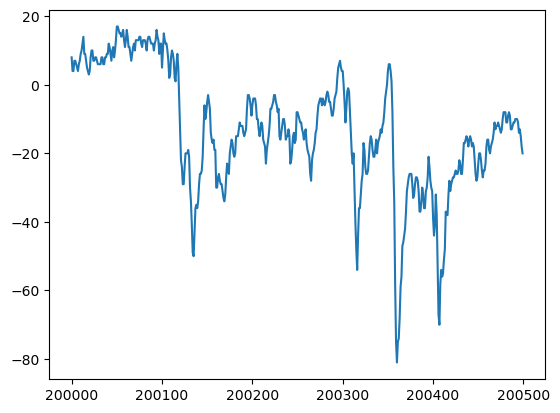

In [5]:
plt.figure()
plt.plot(series.index, series)
plt.show

In [6]:
data['DateTime']= pd.to_datetime(data['DateTime'])
data = data.set_index('DateTime')


Text(0.5, 1.0, 'Dst vs Date')

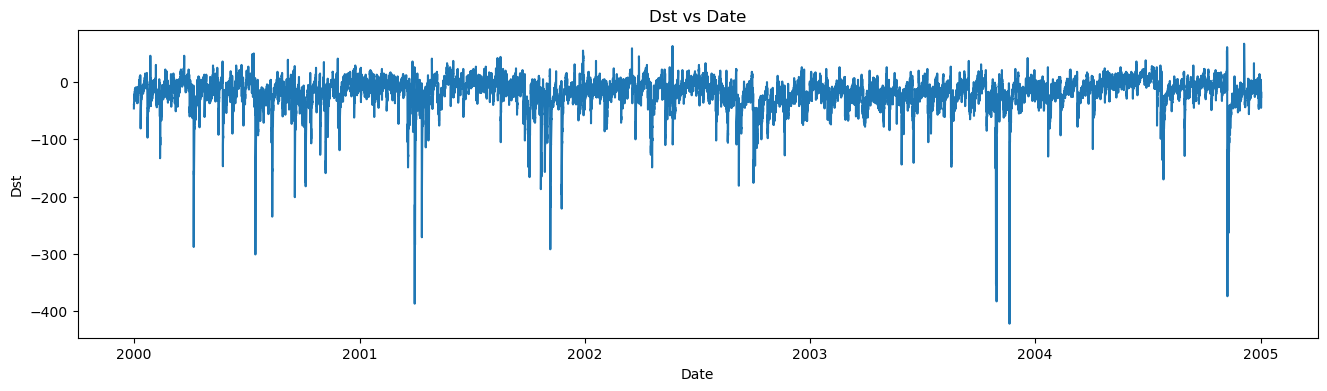

In [7]:
series = data.loc['2000-01-01': '2005-01-01', 'Dst']

plt.figure(figsize = (16,4))
plt.plot(series.index,series)
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst vs Date")


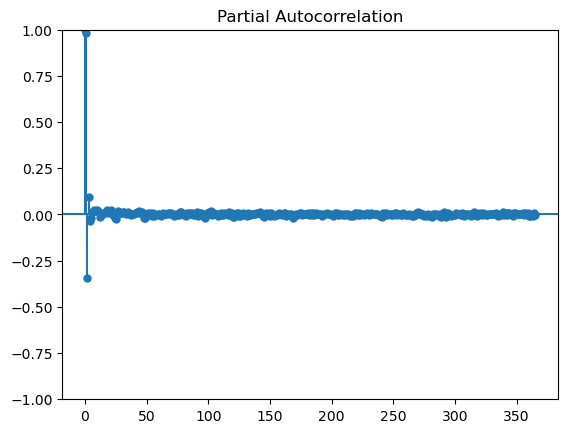

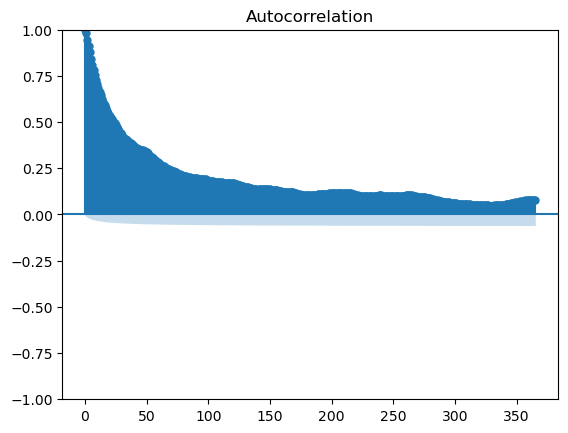

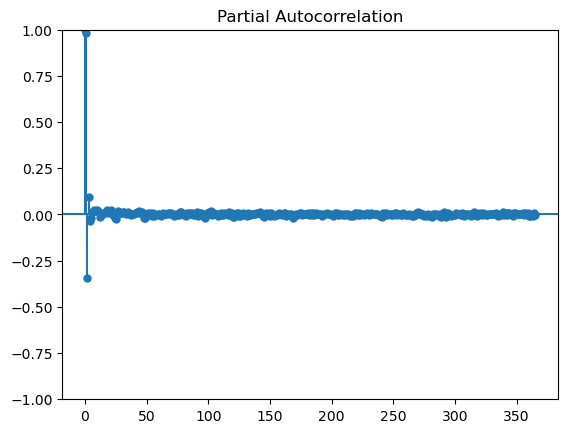

In [8]:
plot_acf(series,lags = 365)
plot_pacf(series, lags = 365)

In [ ]:
model = auto_arima(
    series,
    seasonality = False,
    trace = True, 
    stepwise = True 
)

print(model.summary()) 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=271543.973, Time=7.98 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=277159.732, Time=0.77 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=272135.222, Time=1.66 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=271596.221, Time=3.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=277157.733, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=271552.310, Time=15.36 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=271549.283, Time=6.40 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=271544.558, Time=39.84 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=44.95 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=271574.226, Time=4.15 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=271545.771, Time=10.27 sec


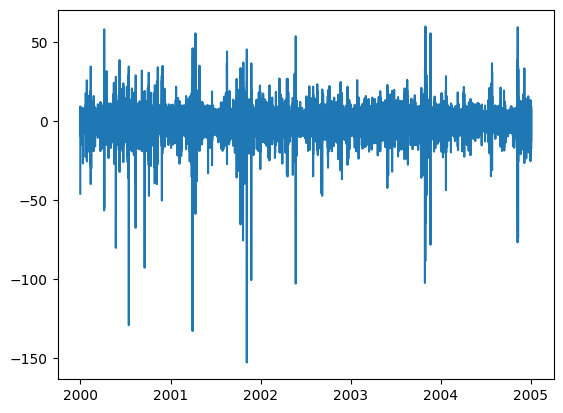

In [ ]:
residuals = model.resid()


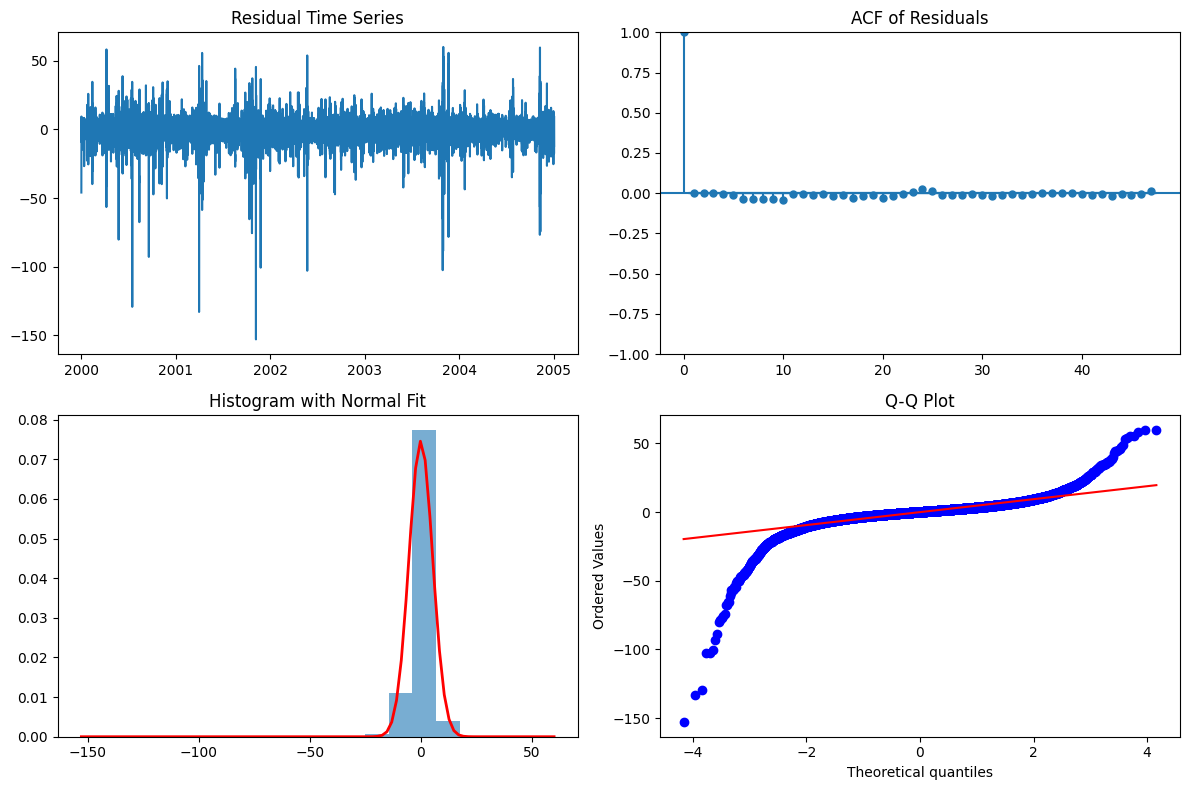

In [28]:
diagnostic_plot(residuals)

Interesting, the QQ plot shows that the residual distribution deviates from the idea around -2 and 2 standard deviations below and above the mean. I'm going try ARIMAX to improve the model. 

In [37]:
from pmdarima.model_selection import train_test_split

exog_cols = ['Kp', 'AE' , 'Esw']

target_col = ['Dst']

df = data.loc['2000-01-01':'2005-01-01', target_col + exog_cols].dropna()

y = df['Dst']
x = df[exog_cols].dropna()

split_date = '2004-01-01'

y_train = y.loc[:split_date]
y_test  = y.loc[split_date:]

X_train = x.loc[:split_date]
X_test  = x.loc[split_date:]

print(len(x))
print(len(y))

43775
43775


In [38]:
model = auto_arima(
    y_train,
    X=X_train,
    seasonal=False,
    trace=True,
    stepwise=True
)



Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=217376.573, Time=33.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=221395.091, Time=4.69 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=218068.815, Time=6.98 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=217853.896, Time=5.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=221393.092, Time=8.29 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=217805.484, Time=15.43 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=217769.358, Time=7.30 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=217772.395, Time=32.51 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=217754.619, Time=37.56 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=217812.891, Time=7.72 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=217759.969, Time=28.73 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=217770.257, Time=12.17 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=217759.553, Time=38.06 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=217265.915, Time=30.03 s

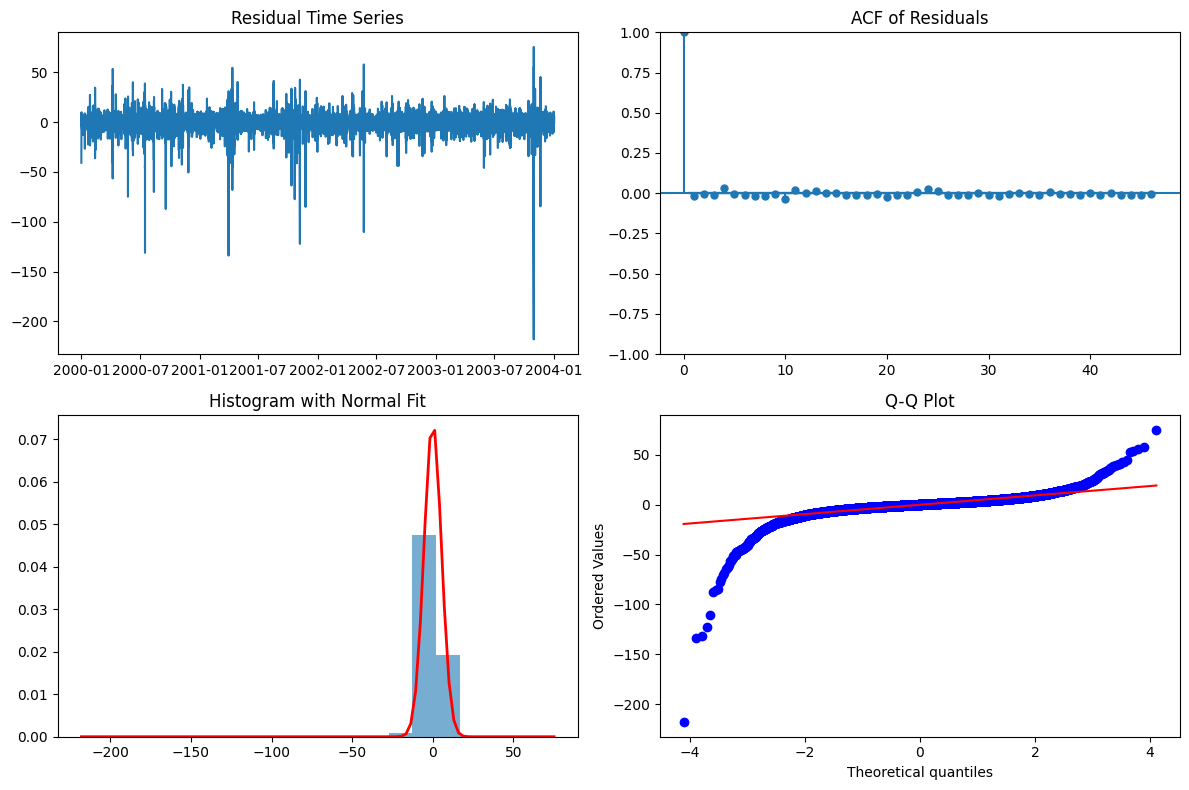

In [40]:
residuals = model.resid()

diagnostic_plot(residuals)

Now let's do another example. 2003, where we have quite a few geomagnetic storms wit a Dst below -50. We will go through the whole process.

In [64]:
import numpy as np 
import pandas as pd 
from diagnostics import diagnostic_plot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
from pmdarima import auto_arima  
from sampling_methods import sample_gaussian, sample_empirical, sample_kde, sample_block

In [65]:
fn = r"C:\Data\fcc_database_v1.hdf5"

data = pd.read_hdf(fn)

In [68]:
data['DateTime']= pd.to_datetime(data['DateTime'])
data = data.set_index('DateTime')

Text(0.5, 1.0, 'Dst vs Date')

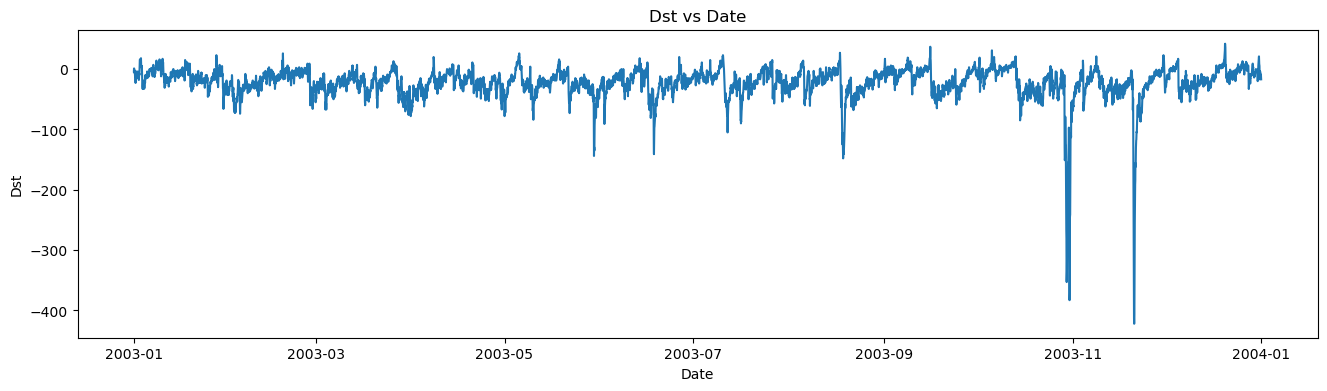

In [70]:
series = data.loc['2003-01-01': '2003-12-31', 'Dst']

plt.figure(figsize = (16,4))
plt.plot(series.index,series)
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst vs Date")

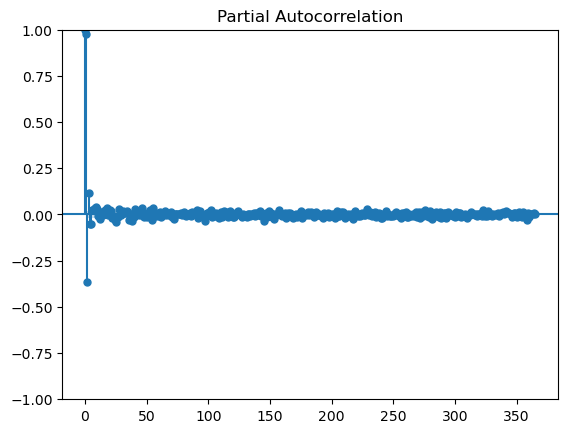

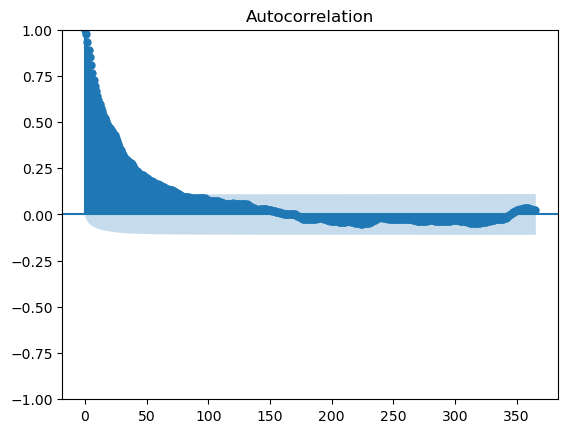

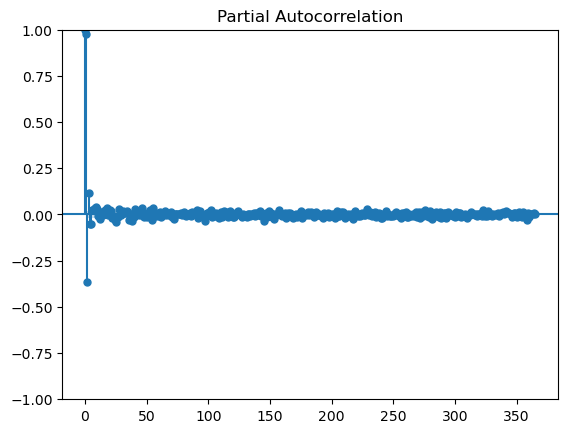

In [71]:
plot_acf(series,lags = 365)
plot_pacf(series, lags = 365)

In [72]:
model = auto_arima(
    series,
    seasonality = False,
    trace = True, 
    stepwise = True 
)

print(model.summary()) 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=55123.307, Time=8.46 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=56453.192, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=55308.520, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=55153.336, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=56451.192, Time=0.12 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=55131.861, Time=3.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=55135.571, Time=2.55 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=55117.851, Time=9.10 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=55133.757, Time=3.18 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=55116.581, Time=10.08 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=55124.839, Time=3.06 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=11.55 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=54994.256, Time=12.38 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=55117.764, Time=9.89 sec
 ARIMA(5,1,3)(0,0,0)[0

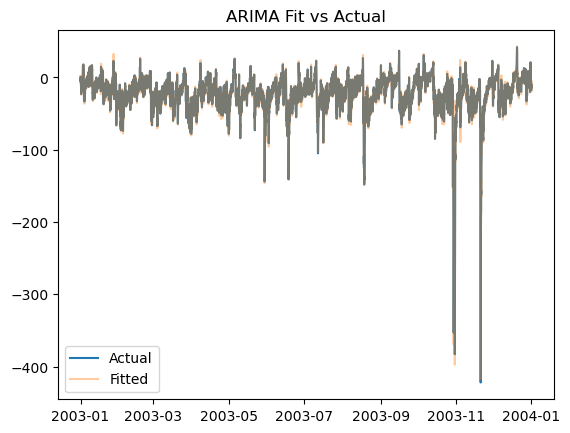

In [81]:
fitted_values = model.predict_in_sample()

plt.figure()
plt.plot(series, label="Actual")
plt.plot(fitted_values, label="Fitted", alpha= 0.4)
plt.legend()
plt.title("ARIMA Fit vs Actual")
plt.show() 

In [82]:
residuals = model.resid()

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

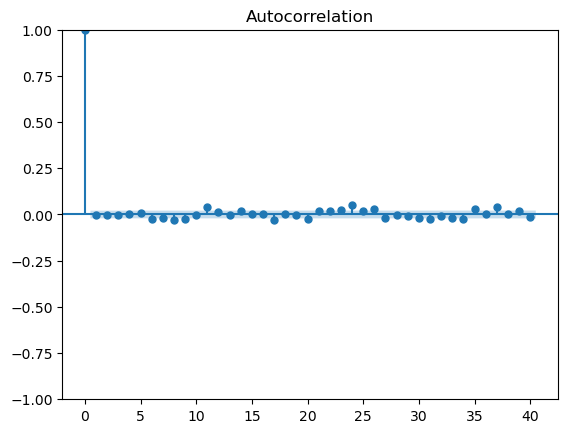

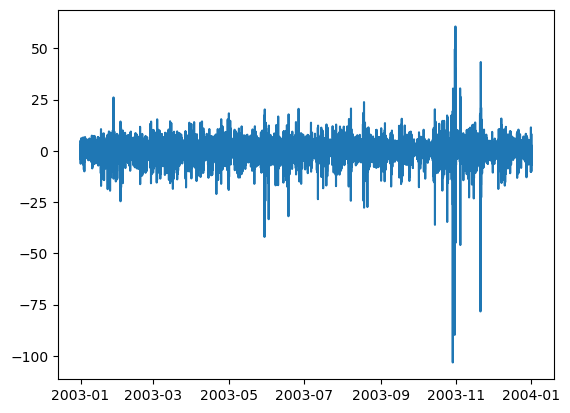

In [83]:
plt.figure()
plot_acf(residuals)
plt.show

plt.figure() 
plt.plot(residuals)
plt.show

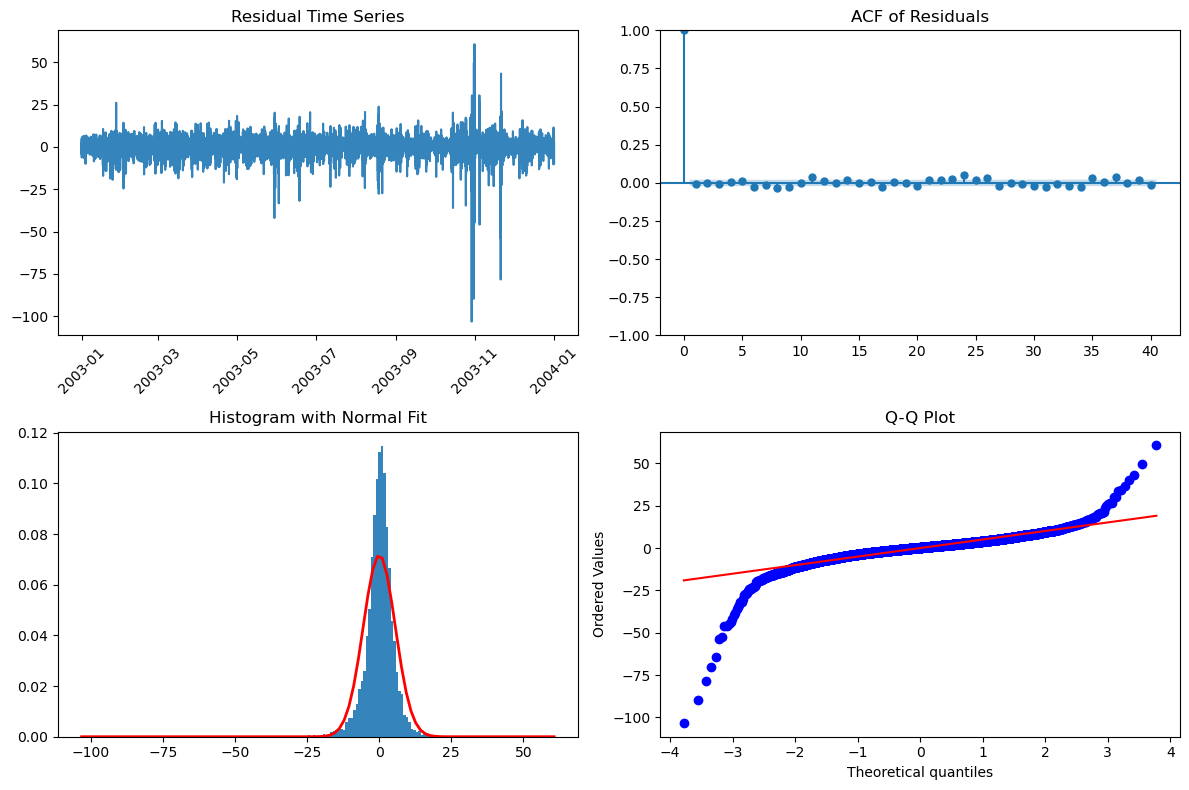

In [84]:
diagnostic_plot(residuals)

In [85]:
print(len(series))

8760


In [87]:
block_results = sample_block(residuals,8760)

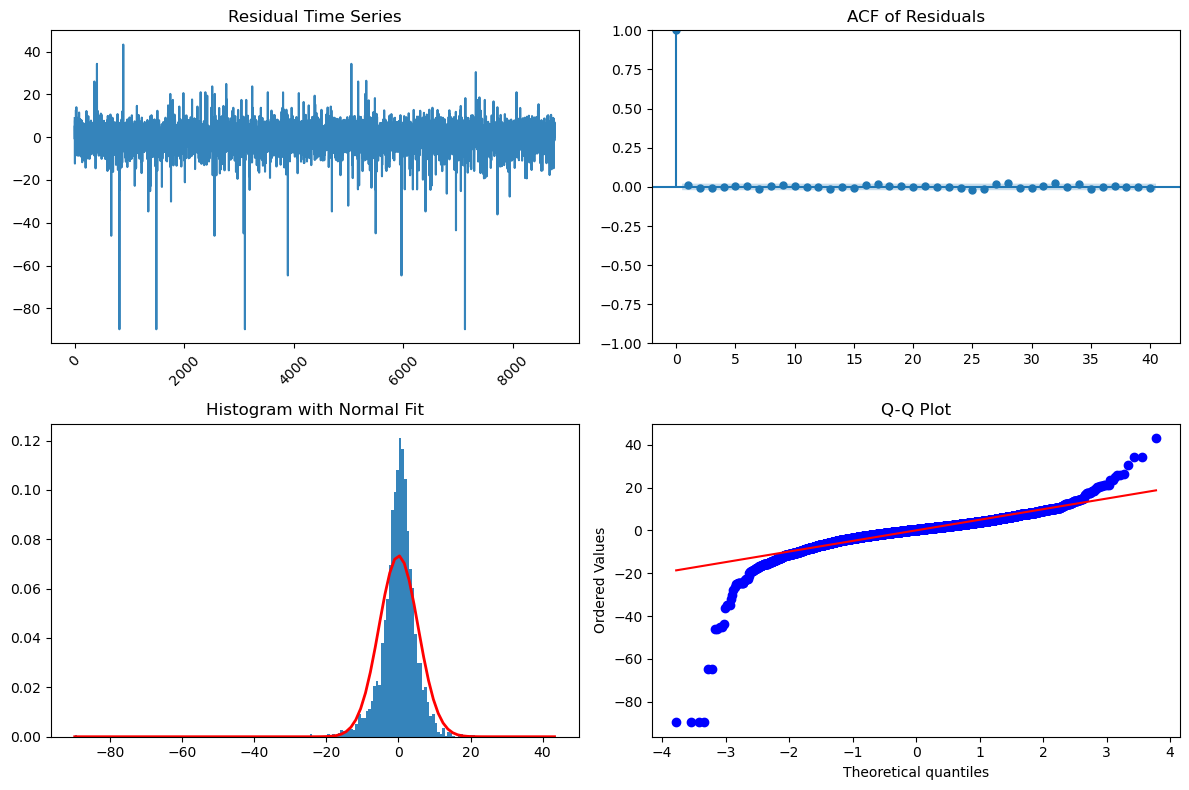

In [88]:
diagnostic_plot(block_results)

In [89]:
from scipy.stats import ks_2samp

block_ks_stat, block_p_value = ks_2samp(residuals, block_results)

print("Block KS Statistic:", block_ks_stat)
print("Block P-value:", block_p_value)

Block KS Statistic: 0.010958904109589041
Block P-value: 0.6688775422430775


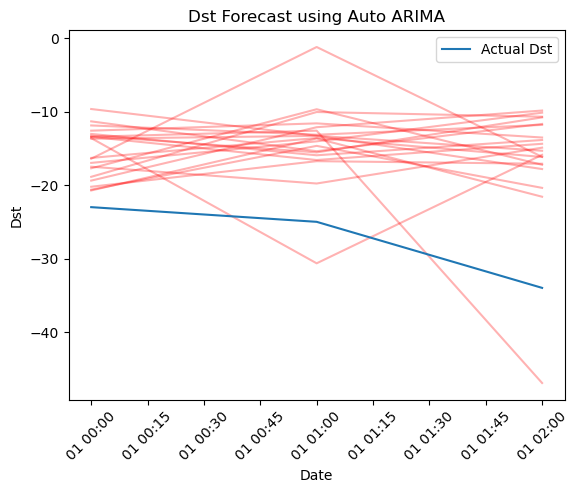

In [95]:
n_periods = 3

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[-1] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'Dst'] 

ensemble_block = []

for i in range(20):

    block_results = sample_block(residuals, n_periods)

    forecast_perturbed = forecast + block_results

    ensemble_block.append(forecast_perturbed)

for i in range(20):
    plt.plot(forecast_index, ensemble_block[i], alpha=0.3, color='red')

plt.plot(future_series.index, future_series, label='Actual Dst')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst Forecast using Auto ARIMA")
plt.legend()
plt.show()

In [102]:
ensemble_array = np.array(ensemble_block)

forecast_mean = np.mean(ensemble_array, axis = 0)

Text(0.5, 1.0, 'Forecast Mean')

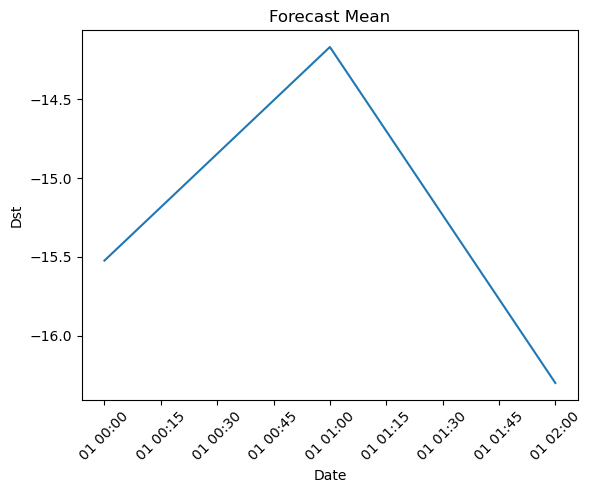

In [106]:
plt.figure()
plt.plot(forecast_index, forecast_mean)
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Forecast Mean")


In [107]:
dst_events = series[series < -50]

for t, v in dst_events.items():
    print(t, v)

2003-01-29 23:00:00 -63.0
2003-01-30 00:00:00 -66.0
2003-01-30 01:00:00 -57.0
2003-02-02 07:00:00 -54.0
2003-02-02 09:00:00 -59.0
2003-02-02 10:00:00 -67.0
2003-02-02 11:00:00 -61.0
2003-02-02 12:00:00 -65.0
2003-02-02 13:00:00 -61.0
2003-02-02 14:00:00 -66.0
2003-02-02 15:00:00 -72.0
2003-02-02 16:00:00 -65.0
2003-02-02 17:00:00 -72.0
2003-02-02 18:00:00 -71.0
2003-02-02 19:00:00 -57.0
2003-02-02 20:00:00 -68.0
2003-02-02 21:00:00 -72.0
2003-02-02 22:00:00 -71.0
2003-02-02 23:00:00 -68.0
2003-02-03 00:00:00 -59.0
2003-02-03 01:00:00 -58.0
2003-02-03 02:00:00 -58.0
2003-02-03 03:00:00 -55.0
2003-02-03 04:00:00 -53.0
2003-02-03 10:00:00 -54.0
2003-02-03 11:00:00 -53.0
2003-02-04 07:00:00 -54.0
2003-02-04 08:00:00 -72.0
2003-02-04 09:00:00 -74.0
2003-02-04 10:00:00 -66.0
2003-02-04 11:00:00 -58.0
2003-02-04 22:00:00 -55.0
2003-02-04 23:00:00 -54.0
2003-02-05 00:00:00 -52.0
2003-02-27 02:00:00 -60.0
2003-02-27 17:00:00 -51.0
2003-02-27 18:00:00 -53.0
2003-02-27 19:00:00 -58.0
2003-02-27 2

In [108]:
series.index.get_loc('2003-11-20 11:00:00')

7763

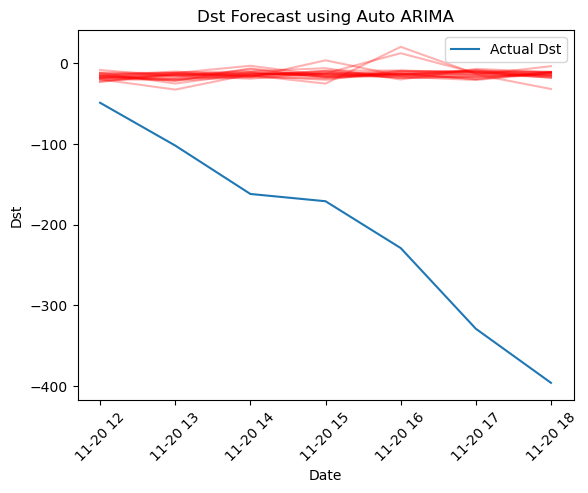

In [110]:
n_periods = 7

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[7763] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'Dst'] 

ensemble_block = []

for i in range(20):

    block_results = sample_block(residuals, n_periods)

    forecast_perturbed = forecast + block_results

    ensemble_block.append(forecast_perturbed)

for i in range(20):
    plt.plot(forecast_index, ensemble_block[i], alpha=0.3, color='red')

plt.plot(future_series.index, future_series, label='Actual Dst')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst Forecast using Auto ARIMA")
plt.legend()
plt.show()

In [111]:
model = auto_arima(
    series.iloc[:7763],
    seasonality = False,
    trace = True, 
    stepwise = True 
)

print(model.summary()) 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=48534.650, Time=3.75 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=49556.785, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=48756.316, Time=0.33 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=48589.299, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=49554.800, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=5.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=48532.894, Time=0.46 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=48591.178, Time=0.68 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=48534.526, Time=0.40 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=48533.198, Time=3.59 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=48532.765, Time=0.49 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=48534.424, Time=0.78 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=48535.198, Time=4.69 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=48530.777, Time=0.24 sec
 ARIMA(2,1,0)(0,0,0)[0]  

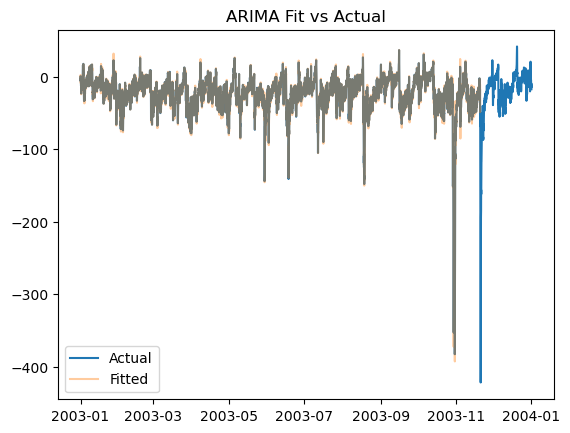

In [112]:
fitted_values = model.predict_in_sample()

plt.figure()
plt.plot(series, label="Actual")
plt.plot(fitted_values, label="Fitted", alpha= 0.4)
plt.legend()
plt.title("ARIMA Fit vs Actual")
plt.show() 

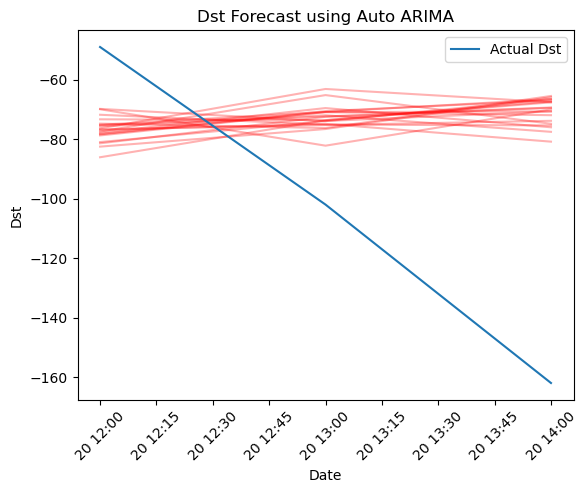

In [113]:
n_periods = 3

forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(
        start = series.index[7763] + pd.Timedelta(hours=1),
        periods = n_periods,
        freq = 'h'
)

future_series = data.loc[forecast_index, 'Dst'] 

ensemble_block = []

for i in range(20):

    block_results = sample_block(residuals, n_periods)

    forecast_perturbed = forecast + block_results

    ensemble_block.append(forecast_perturbed)

for i in range(20):
    plt.plot(forecast_index, ensemble_block[i], alpha=0.3, color='red')

plt.plot(future_series.index, future_series, label='Actual Dst')
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Dst")
plt.title("Dst Forecast using Auto ARIMA")
plt.legend()
plt.show()